# T60 AUV 平面 Lissajous Policy 评估

评估当前 `t60_trajectory_precision_v16.json` 对应的最新 `t60_precision_v16` 运行，并固定使用 `model_499.pt`。该 policy 以 25 Hz 更新，使用 `z ~ Normal(μ, σ)`、`action = tanh(z)` 的有界推进器动作分布、无注入噪声且确定性延迟 50 ms 的融合状态、roll/pitch/yaw 分轴且精度半宽 2.5° 的 `precision_v9` reward、201 维 `mlp_history_8` Actor、Actor `3e-5` 与 Critic `3e-4` 的固定学习率、完整 6×6 CFD 水动力和当前 T1–T8 实测三轴推力曲线。目标姿态始终保持 `roll=pitch=0`，仅让 yaw 跟随水平速度方向。

本次轨迹为包络 **5 × 3 m**、固定深度（`z` 振幅严格为 `0`）、目标线速度 **0.35 m/s** 的平面 Lissajous；不施加水流，也不采样 Domain Randomization。运行结束后自动绘制并保存 T1–T8 的有界电机指令。

In [ ]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
from IPython.display import display
from simulation.domain_randomization import load_domain_randomization_spec_json
from simulation.training.campaign import configure_plots, run_command
from simulation.training.evaluation.metrics import (
    collect_summary_df, load_eval_log, plot_eval_detail, quick_numeric_report,
)
from simulation.training.recipe import (
    ExperimentSpec, load_training_recipe, run_input_paths,
)

configure_plots()
ISAACLAB_ROOT = Path.home() / 'IsaacLab'
RLPOLICY_ROOT = REPO_ROOT / 'simulation/rlpolicy'
RECIPE_PATH = REPO_ROOT / 'simulation/training/recipes/t60_trajectory_precision_v16.json'
RUN_NAME = 't60_precision_v16'
RECIPE = load_training_recipe(RECIPE_PATH)
SPEC = ExperimentSpec(
    isaaclab_root=ISAACLAB_ROOT,
    rlpolicy_root=RLPOLICY_ROOT,
    mlp_architecture=RECIPE.mlp_architecture,
)
CHECKPOINT = 'model_499.pt'
CHECKPOINT_PATH = max(
    SPEC.logs_root.glob(f'*_{RUN_NAME}/{CHECKPOINT}'),
    key=lambda checkpoint_path: checkpoint_path.stat().st_mtime,
)
POLICY_RUN_DIR = CHECKPOINT_PATH.parent
ACTIVE_RUN = POLICY_RUN_DIR.name
RUN_INPUTS = run_input_paths(POLICY_RUN_DIR)
RUN_RECIPE = load_training_recipe(RUN_INPUTS.recipe)
RUN_DR = load_domain_randomization_spec_json(RUN_INPUTS.domain_randomization)

TRAJECTORY = 'lissajous'
TRAJECTORY_MAX_SPEED_MPS = 0.25
TRAJECTORY_SIZE_X_M = 5.0
TRAJECTORY_SIZE_Y_M = 3.0
TRAJECTORY_SIZE_Z_M = 0.0
TRAJECTORY_AMP_X_M = TRAJECTORY_SIZE_X_M / 2.0
TRAJECTORY_AMP_Y_M = TRAJECTORY_SIZE_Y_M / 2.0
TRAJECTORY_AMP_Z_M = TRAJECTORY_SIZE_Z_M / 2.0
DURATION_S = 60.0
EVALUATION_LABEL = (
    f'{Path(CHECKPOINT).stem}_5x3_planar_lissajous_vmax_{TRAJECTORY_MAX_SPEED_MPS:.2f}_nominal'
    .replace('.', 'p')
)

print(f'run: {POLICY_RUN_DIR}')
print(f'checkpoint: {CHECKPOINT}')
print(f'recipe: {RUN_RECIPE.name} / reward: {RUN_RECIPE.reward_profile}')
print(f'DR: {RUN_DR.name} / schema: {RUN_DR.schema_version}')
print(f'trajectory: {TRAJECTORY} with max speed {TRAJECTORY_MAX_SPEED_MPS:.2f} m/s')
print(f'curve envelope: {TRAJECTORY_SIZE_X_M:.1f} × {TRAJECTORY_SIZE_Y_M:.1f} × {TRAJECTORY_SIZE_Z_M:.1f} m')
print('fixed world-frame current: none')


run: /home/jining_yang/isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-29_05-01-06_t60_precision_v16
checkpoint: model_499.pt
recipe: t60-trajectory-precision-v16 / reward: precision_v9
DR: auv-open-water-openfoam-hydrodynamics-dr-v9--t60-trajectory-precision-v16 / schema: 9
trajectory: lissajous with max speed 0.35 m/s
curve envelope: 5.0 × 3.0 × 0.0 m
fixed world-frame current: none


## 运行平面 Lissajous 评估

蓝线为目标，橙线为真实轨迹。轨迹始终位于水平面内，无外加水流；60 秒结束后窗口自动关闭并写出 `logs.csv`。

In [2]:
VISUALIZATION_COMMAND = [
    './isaaclab.sh', '-p', SPEC.eval_script,
    '--task', SPEC.task_name,
    '--checkpoint', str(CHECKPOINT_PATH),
    '--trajectory', TRAJECTORY,
    '--trajectory_speed', str(TRAJECTORY_MAX_SPEED_MPS),
    '--trajectory_amp_x', str(TRAJECTORY_AMP_X_M),
    '--trajectory_amp_y', str(TRAJECTORY_AMP_Y_M),
    '--trajectory_amp_z', str(TRAJECTORY_AMP_Z_M),
    '--duration', str(DURATION_S),
    '--num_envs', '1',
    '--seed', '42',
    '--evaluation_label', EVALUATION_LABEL,
    '--align_initial_target',
]
run_command(
    VISUALIZATION_COMMAND,
    cwd=ISAACLAB_ROOT,
    execute=True,
    label=f'{Path(CHECKPOINT).stem.upper()} PLANAR LISSAJOUS',
)


[MODEL_499 PLANAR LISSAJOUS]
./isaaclab.sh -p source/isaaclab_tasks/isaaclab_tasks/direct/isaac-auv-env/simulation/training/evaluation/cli.py --task Isaac-AUV-Traj-Direct-v1 --checkpoint ../isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-29_05-01-06_t60_precision_v16/model_499.pt --trajectory lissajous --trajectory_speed 0.35 --trajectory_amp_x 2.5 --trajectory_amp_y 1.5 --trajectory_amp_z 0.0 --duration 60.0 --num_envs 1 --seed 42 --evaluation_label model_499_5x3_planar_lissajous_vmax_0p35_nominal --align_initial_target

H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H    H   
[INFO] Using python from: /home/jining_yang/miniconda3/envs/env_isaaclab/bin/python
[INFO][AppLauncher]: Using device: cuda:0
[INFO][AppLauncher]: Loading experience file: /home/jining_yang/IsaacLab/apps/isaaclab.python.kit
Loading user config located at: '/home/jining_yang/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/is

0

## 跟踪结果

,checkpoint_name,position_rmse,steady_position_rmse,steady_position_error_p95,steady_position_bias_norm_m,steady_position_x_rmse_m,steady_position_y_rmse_m,steady_position_z_rmse_m,steady_cross_track_position_error_rmse_m,steady_attitude_error_rmse_deg,steady_mean_nose_to_target_heading_angle_deg,mean_thruster_wrench_force_norm_n,minimum_vehicle_boundary_clearance_m,mean_water_current_norm,max_water_current_norm,mean_reward_per_step
0,model_499.pt,0.029316,0.030384,0.085873,0.00437,0.018983,0.023286,0.004536,0.028809,1.523627,0.636943,3.389045,0.425262,0.0,0.0,0.955407


,trajectory,evaluated_checkpoints,best_position_rmse,median_position_rmse,best_velocity_rmse
0,lissajous,1,0.029316,0.029316,0.025911


loaded 1500 time-aligned rows from /home/jining_yang/isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-29_05-01-06_t60_precision_v16/evaluation/model_499_model_499_5x3_planar_lissajous_vmax_0p35_nominal_trajectory_eval/logs.csv
Saved: /home/jining_yang/isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-29_05-01-06_t60_precision_v16/evaluation/model_499_model_499_5x3_planar_lissajous_vmax_0p35_nominal_trajectory_eval/tracking_eval_env0.png


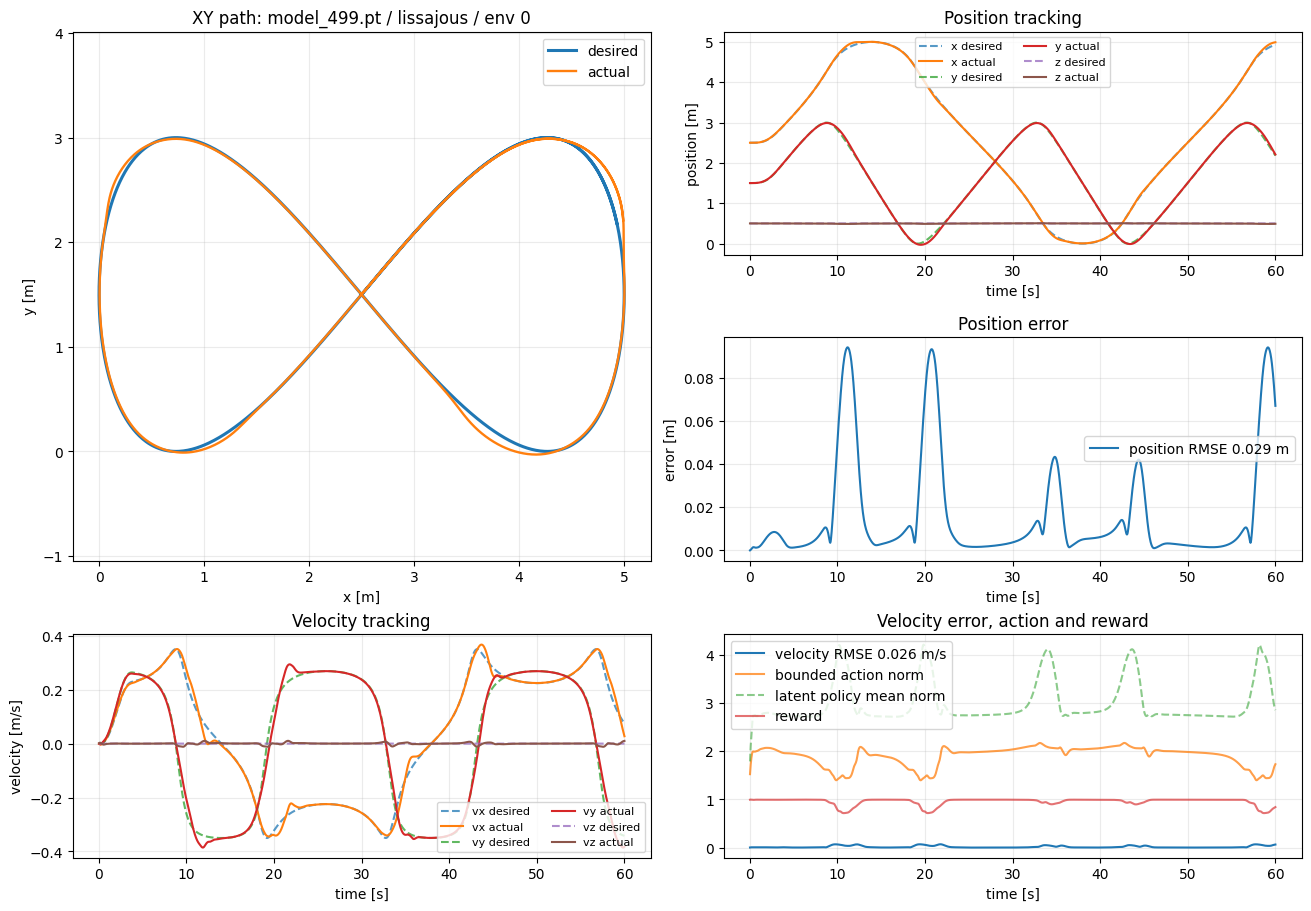

In [3]:
summary_df = collect_summary_df(SPEC, ACTIVE_RUN, case_label=EVALUATION_LABEL)
summary_df = summary_df[
    (summary_df['checkpoint_name'] == CHECKPOINT)
    & (summary_df['trajectory'] == TRAJECTORY)
].copy()
display(summary_df[[
    'checkpoint_name', 'position_rmse', 'steady_position_rmse',
    'steady_position_error_p95', 'steady_position_bias_norm_m',
    'steady_position_x_rmse_m', 'steady_position_y_rmse_m',
    'steady_position_z_rmse_m', 'steady_cross_track_position_error_rmse_m',
    'steady_attitude_error_rmse_deg', 'steady_mean_nose_to_target_heading_angle_deg',
    'mean_thruster_wrench_force_norm_n', 'minimum_vehicle_boundary_clearance_m',
    'mean_water_current_norm', 'max_water_current_norm',
    'mean_reward_per_step',
]])
display(quick_numeric_report(summary_df))

detail_df, detail_path = load_eval_log(
    SPEC, ACTIVE_RUN, CHECKPOINT, TRAJECTORY, EVALUATION_LABEL,
)
print(f'loaded {len(detail_df)} time-aligned rows from {detail_path}')
detail_figure = plot_eval_detail(
    SPEC, ACTIVE_RUN, detail_df, CHECKPOINT, TRAJECTORY,
    case_label=EVALUATION_LABEL, env_id=0, save=True,
)
display(detail_figure)
plt.close(detail_figure)


## T1–T8 有界电机指令

绘制实际送入环境的 `action_0...action_7`，即 `tanh` 后的 `[-1, 1]` 指令；灰色区域是对应 PWM 1475–1525 μs 的零推力死区。

Saved: /home/jining_yang/isaac-auv-env/simulation/rlpolicy/auv_traj_mlp_history_8/2026-08-29_05-01-06_t60_precision_v16/evaluation/model_499_model_499_5x3_planar_lissajous_vmax_0p35_nominal_trajectory_eval/thruster_actions_env0.png


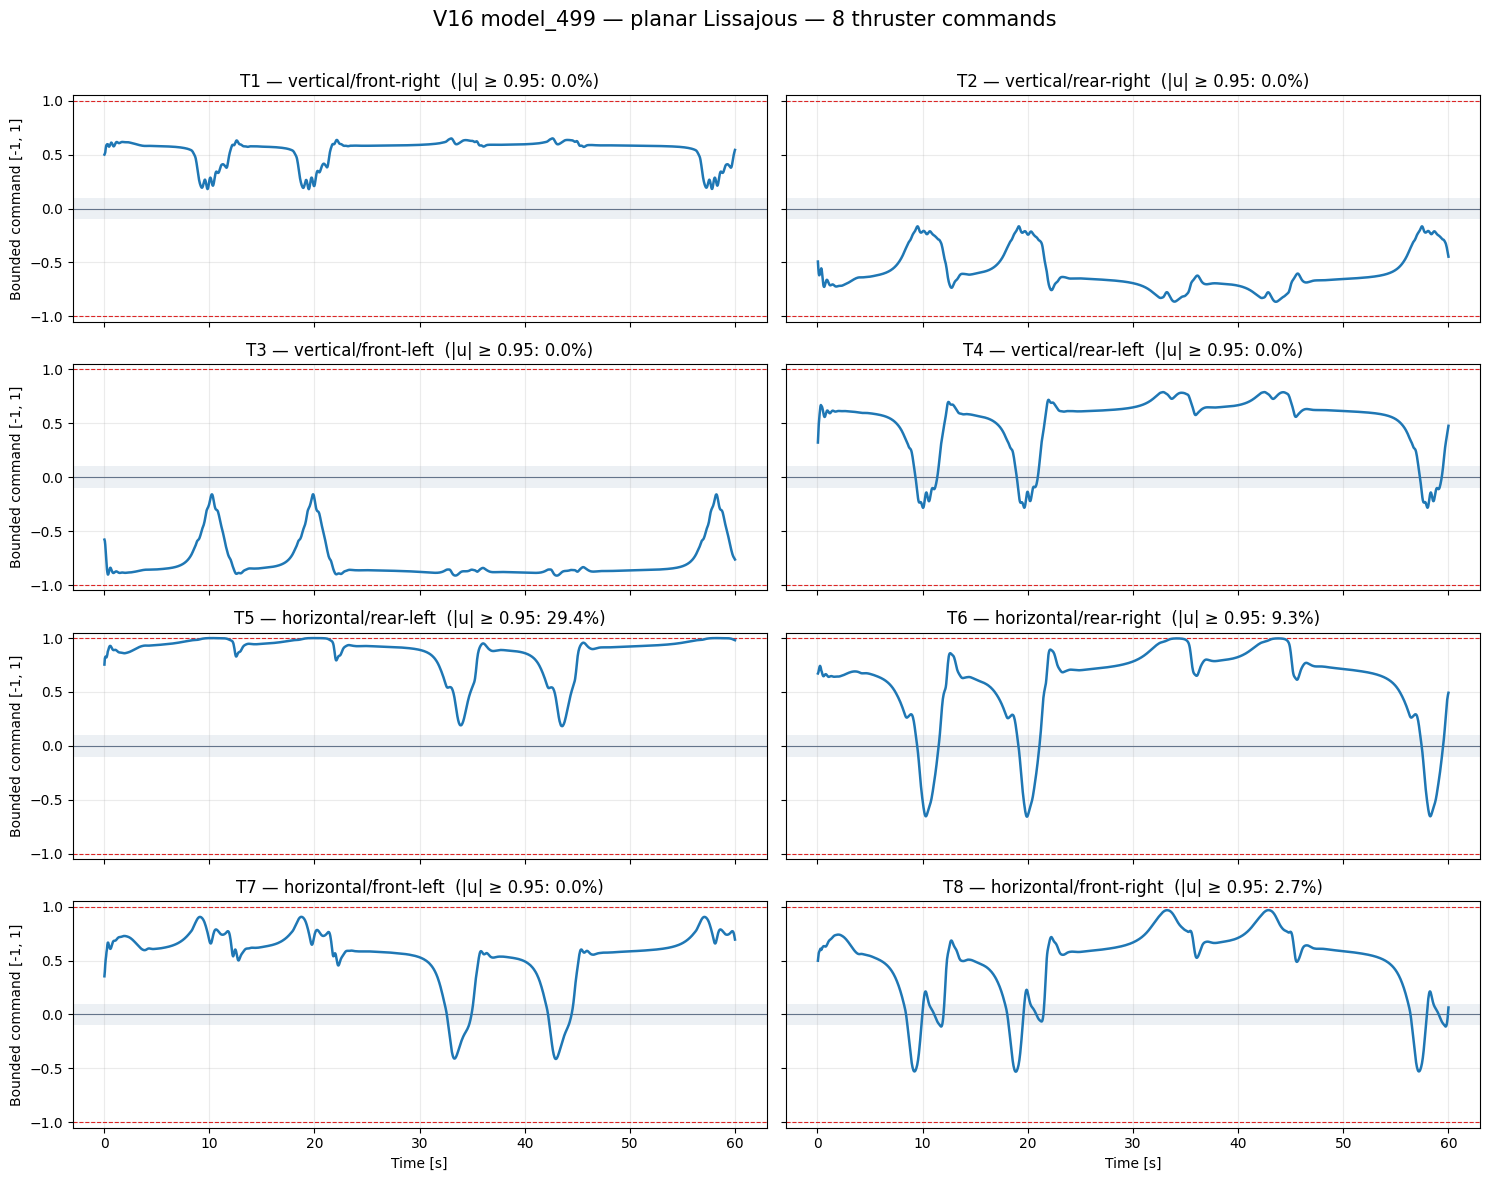

In [4]:
THRUSTER_INSTALLATIONS = (
    'vertical/front-right', 'vertical/rear-right',
    'vertical/front-left', 'vertical/rear-left',
    'horizontal/rear-left', 'horizontal/rear-right',
    'horizontal/front-left', 'horizontal/front-right',
)
env0 = detail_df.loc[detail_df['env_id'] == 0].sort_values('time').copy()
deadband_command = 25.0 / 250.0
figure, axes = plt.subplots(4, 2, figsize=(15, 12), sharex=True, sharey=True)
for thruster_index, axis in enumerate(axes.flat):
    command = env0[f'action_{thruster_index}']
    saturation_fraction = 100.0 * (command.abs() >= 0.95).mean()
    axis.axhspan(
        -deadband_command, deadband_command, color='#cbd5e1', alpha=0.35, linewidth=0,
    )
    axis.axhline(0.0, color='#64748b', linewidth=0.8)
    axis.axhline(1.0, color='#dc2626', linewidth=0.8, linestyle='--')
    axis.axhline(-1.0, color='#dc2626', linewidth=0.8, linestyle='--')
    axis.plot(env0['time'], command, linewidth=1.8)
    axis.set_title(
        f'T{thruster_index + 1} — {THRUSTER_INSTALLATIONS[thruster_index]}'
        f'  (|u| ≥ 0.95: {saturation_fraction:.1f}%)'
    )
    axis.set_ylim(-1.05, 1.05)
    axis.grid(True, alpha=0.25)
    if thruster_index % 2 == 0:
        axis.set_ylabel('Bounded command [-1, 1]')
    if thruster_index >= 6:
        axis.set_xlabel('Time [s]')
figure.suptitle(
    f'V16 {Path(CHECKPOINT).stem} — planar Lissajous — 8 thruster commands',
    fontsize=15,
)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
thruster_plot_path = Path(detail_path).parent / 'thruster_actions_env0.png'
figure.savefig(thruster_plot_path, dpi=180, bbox_inches='tight')
print(f'Saved: {thruster_plot_path}')
display(figure)
plt.close(figure)
